# Causal ML example



In [29]:
import numpy as np
import pandas as pd
from econml.dml import CausalForestDML

import matplotlib.pyplot as plt

## Make data

In [30]:
n_samples = 10000

n_X = 4

## Features
X = np.random.normal(size=(n_samples, n_X))

## Treatments
T = np.random.normal(size=(n_samples))


In [31]:
## Make outcome: nonlinear treatment effect only
w_eff = 2
y = w_eff * T * (T > 0)

## Noise on Y
y_e = np.random.normal(loc = 0.0, scale = 0.1, size=(n_samples))
y = y + y_e 

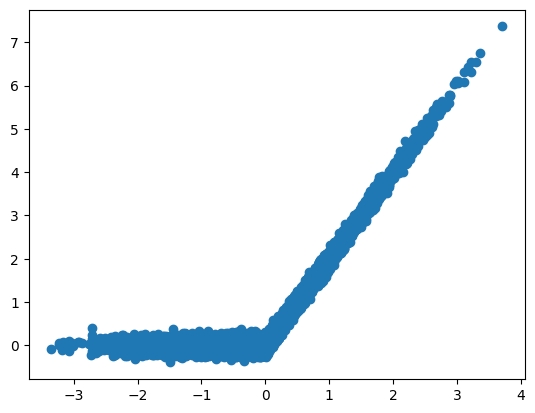

In [32]:
plt.plot(T, y, 'o')

In [33]:
## Test set for plotting
n_test = 100
X_test0 = np.zeros((n_test, n_X))


## Standard model

In [34]:
cfdml = CausalForestDML(model_y='auto',
                        model_t='auto',
                        discrete_treatment=False,
                        cv=3,
                        n_estimators=4000,
                        random_state=123)
cfdml.fit(y, T, X=X)

In [35]:
# cfdml.shap_values(X)

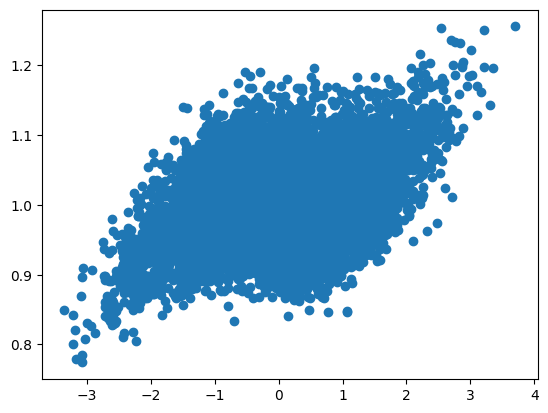

In [36]:
tau = cfdml.effect(X)
plt.plot(T, tau, 'o')

## Treatment in features

In [37]:
X_T = np.concatenate((X, T[:, np.newaxis]), axis=1)

print(X_T)

[[ 0.5127417   0.69936809 -1.34388932  0.58644744 -0.29330924]
 [ 0.65484792  0.17878558 -1.71768715 -0.79351342  0.76722115]
 [-1.47959952 -0.31043974 -0.14886751  0.03212088 -2.48345222]
 ...
 [-0.21894072 -1.6542203  -0.07026435  1.40811653  1.23093059]
 [ 1.81697252 -0.2570508  -2.96961419  1.27581624 -1.22592189]
 [ 0.27189095  0.2898487   1.20007856  0.94624507 -0.76861205]]


In [40]:
T_test1 = np.linspace(-3, 3, 100)[:, np.newaxis]

X_test1 = np.concatenate((X_test0, T_test1), axis=1)

In [41]:
X_test1

array([[ 0.        ,  0.        ,  0.        ,  0.        , -3.        ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.93939394],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.87878788],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.81818182],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.75757576],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.6969697 ],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.63636364],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.57575758],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.51515152],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.45454545],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.39393939],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.33333333],
       [ 0.        ,  0.        ,  0.        ,  0.        , -2.27272727],
       [ 0.        ,  0.        ,  0. 

In [46]:
cfdml = CausalForestDML(model_y='auto',
                        model_t='auto',
                        discrete_treatment=False,
                        cv=3,
                        n_estimators=4000,
                        random_state=123)
cfdml.fit(y, T, X=X_T)

In [47]:
tau1 = cfdml.effect(X_test1)
# plt.plot(T, tau, 'o')
tau1

array([-0.65127529, -0.65127529, -0.65127529, -0.65127529, -0.65127529,
       -0.65127529, -0.65420035, -0.67614561, -0.55430943, -0.48185295,
       -0.46347849, -0.44263625, -0.4403863 , -0.27693444,  0.02024662,
        0.19949861,  0.81943347,  1.08787924,  1.33798848,  1.92983304,
        2.34033232,  2.73098252,  3.23191968,  3.59204484,  3.83370837,
        3.76314326,  3.94963939,  3.74903386,  3.99429562,  3.76284322,
        4.3156898 ,  4.24307617,  4.75510562,  4.37839891,  5.10398063,
        5.07018573,  5.19434166,  5.14371246,  5.0711344 ,  4.97564956,
        4.12015376,  3.57214601,  3.40767064,  3.16932909,  3.10441796,
        3.38197416,  3.83732556,  3.61917259,  3.68915064,  3.66068947,
        3.42570097,  2.69251053,  3.5573459 ,  2.74244634,  2.57772088,
        1.95060005,  1.73330279,  1.61563997,  1.54943173,  1.08721036,
        0.6938602 ,  0.37073667,  0.28938109,  0.39808098,  0.20651573,
        0.51951865,  0.92510991,  1.33802877,  2.30830257,  2.64

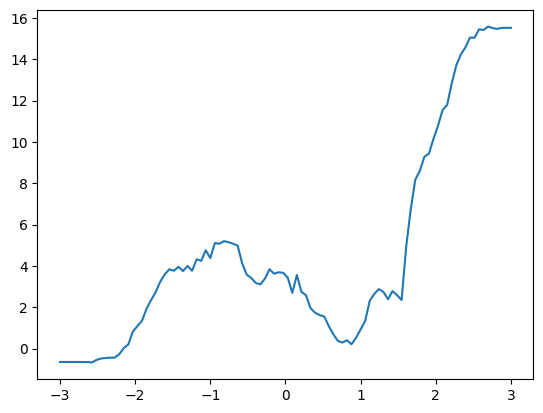

In [51]:
plt.plot(X_test1[:,4], tau1)